In [1]:
import os
import nibabel as nib

ct_path = "C:\\My Projects\\brain-ct-hemorrhage-segmentation\\Data\\computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1\\ct_scans"
mask_path = "C:\\My Projects\\brain-ct-hemorrhage-segmentation\\Data\\computed-tomography-images-for-intracranial-hemorrhage-detection-and-segmentation-1.3.1\\masks"

# get one sample file
ct_file = sorted(os.listdir(ct_path))[0]
mask_file = sorted(os.listdir(mask_path))[0]

print("CT file:", ct_file)
print("Mask file:", mask_file)

# load
ct_img = nib.load(os.path.join(ct_path, ct_file))
mask_img = nib.load(os.path.join(mask_path, mask_file))

# convert to numpy
ct_data = ct_img.get_fdata()
mask_data = mask_img.get_fdata()

# print info
print("\nCT shape:", ct_data.shape)
print("Mask shape:", mask_data.shape)

print("\nCT dtype:", ct_data.dtype)
print("Mask dtype:", mask_data.dtype)

print("\nCT spacing:", ct_img.header.get_zooms())
print("Mask spacing:", mask_img.header.get_zooms())

CT file: 049.nii
Mask file: 049.nii

CT shape: (512, 512, 39)
Mask shape: (512, 512, 39)

CT dtype: float64
Mask dtype: float64

CT spacing: (np.float32(0.41210938), np.float32(0.41210938), np.float32(5.0))
Mask spacing: (np.float32(0.41210938), np.float32(0.41210938), np.float32(5.0))


In [2]:
import nibabel as nib

print("CT orientation:", nib.aff2axcodes(ct_img.affine))
print("Mask orientation:", nib.aff2axcodes(mask_img.affine))

CT orientation: ('L', 'A', 'S')
Mask orientation: ('L', 'A', 'S')


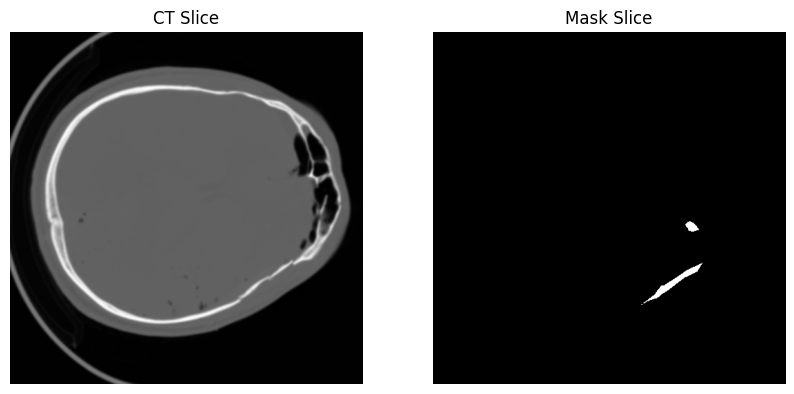

In [3]:
import matplotlib.pyplot as plt

slice_idx = 20  # middle slice

plt.figure(figsize=(10,5))

# CT image
plt.subplot(1,2,1)
plt.imshow(ct_data[:, :, slice_idx], cmap='gray')
plt.title("CT Slice")
plt.axis("off")

# Mask
plt.subplot(1,2,2)
plt.imshow(mask_data[:, :, slice_idx], cmap='gray')
plt.title("Mask Slice")
plt.axis("off")

plt.show()

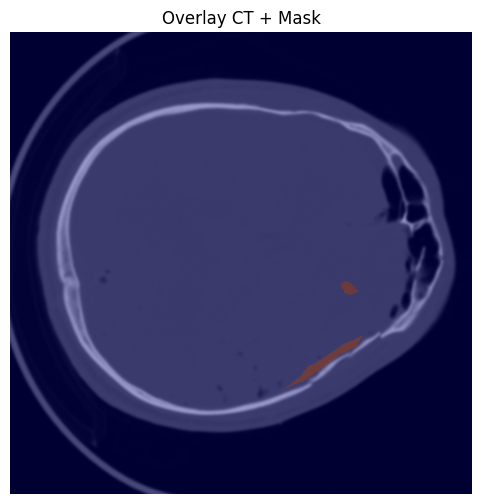

In [4]:
plt.figure(figsize=(6,6))
plt.imshow(ct_data[:, :, slice_idx], cmap='gray')
plt.imshow(mask_data[:, :, slice_idx], cmap='jet', alpha=0.4)
plt.title("Overlay CT + Mask")
plt.axis("off")
plt.show()

# The seeker

In [49]:
import os
import numpy as np
import nibabel as nib

def fix_mask(ct, mask):
    # --- YOUR REAL LOGIC HERE ---
    valid = (ct >= 0) & (ct <= 300)
    return (mask * valid).astype(np.uint8)


max_changed = 0
best_info = None

files = sorted(os.listdir(ct_path))

for f in files:
    ct = nib.load(os.path.join(ct_path, f)).get_fdata()
    mask = nib.load(os.path.join(mask_path, f)).get_fdata()

    mask = (mask > 0).astype(np.uint8)
    mask_fixed = fix_mask(ct, mask)

    for i in range(ct.shape[2]):  # adjust axis if needed
        m_before = mask[:, :, i]
        m_after  = mask_fixed[:, :, i]

        changed = (m_before != m_after).sum()

        if changed > max_changed:
            max_changed = changed
            best_info = {
                "file": f,
                "slice": i,
                "changed_pixels": int(changed)
            }

print("\n✅ RESULT")
print(best_info)
print("Max changed pixels:", max_changed)


✅ RESULT
{'file': '076.nii', 'slice': 39, 'changed_pixels': 178}
Max changed pixels: 178


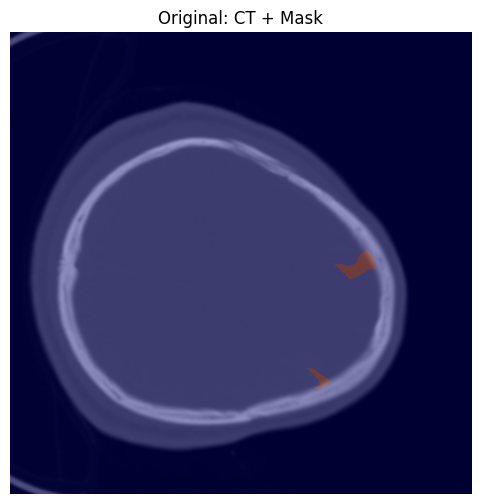

TypeError: FigureCanvasAgg.print_png() got an unexpected keyword argument 'cmap'

<Figure size 640x480 with 0 Axes>

In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os

file_name = "076.nii"
slice_idx = 39

ct = nib.load(os.path.join(ct_path, file_name)).get_fdata()
mask = nib.load(os.path.join(mask_path, file_name)).get_fdata()

mask = (mask > 0).astype(np.uint8)

plt.figure(figsize=(6,6))
plt.imshow(ct[:, :, slice_idx], cmap='gray')
plt.imshow(mask[:, :, slice_idx], cmap='jet', alpha=0.4)
plt.title("Original: CT + Mask")
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

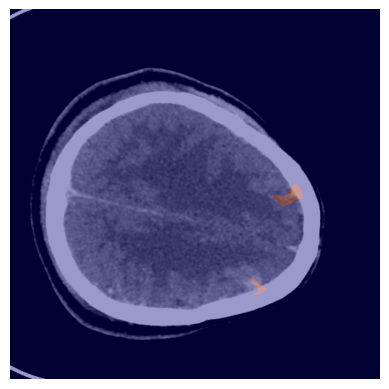

In [51]:
def window_ct(img, level=40, width=80):
    min_val = level - width // 2
    max_val = level + width // 2
    img = np.clip(img, min_val, max_val)
    img = (img - min_val) / (max_val - min_val)
    return img

ct_windowed = window_ct(ct[:, :, slice_idx])

plt.imshow(ct_windowed, cmap='gray')
plt.imshow(mask[:, :, slice_idx], cmap='jet', alpha=0.4)
plt.axis("off")

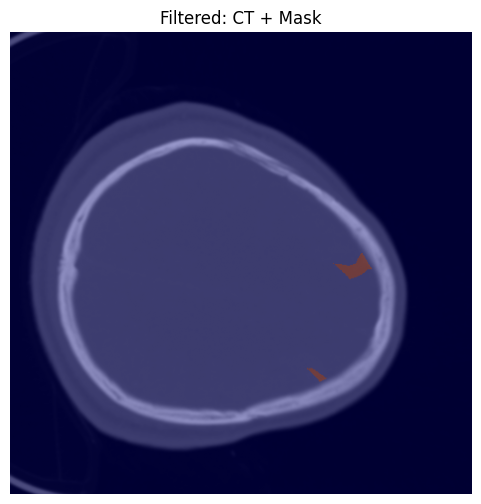

In [52]:
# --- FILTER MASK USING CT VALUES ---

# extract slice
ct_slice = ct[:, :, slice_idx]
mask_slice = mask[:, :, slice_idx]

# apply filtering condition
valid = (ct_slice >= 0) & (ct_slice <= 120)

mask_filtered = (mask_slice * valid).astype(np.uint8)

# visualize result
plt.figure(figsize=(6,6))
plt.imshow(ct_slice, cmap='gray')
plt.imshow(mask_filtered, cmap='jet', alpha=0.4)
plt.title("Filtered: CT + Mask")
plt.axis("off")
plt.show()

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

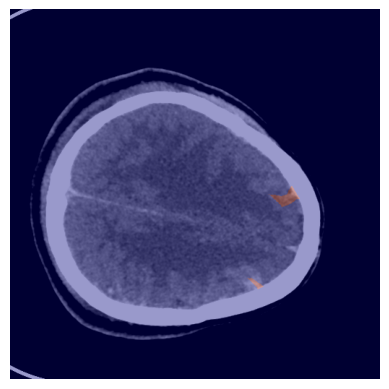

In [53]:
def window_ct(img, level=40, width=80):
    min_val = level - width // 2
    max_val = level + width // 2
    img = np.clip(img, min_val, max_val)
    img = (img - min_val) / (max_val - min_val)
    return img

ct_windowed = window_ct(ct[:, :, slice_idx])

plt.imshow(ct_windowed, cmap='gray')
plt.imshow(mask_filtered, cmap='jet', alpha=0.4)
plt.axis("off")

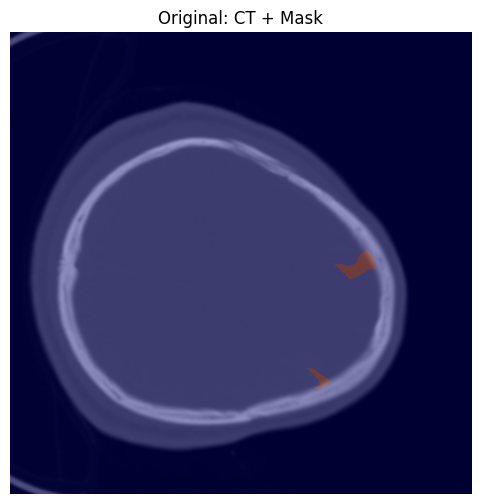

In [54]:
plt.figure(figsize=(6,6))
plt.imshow(ct[:, :, slice_idx], cmap='gray')
plt.imshow(mask[:, :, slice_idx], cmap='jet', alpha=0.4)
plt.title("Original: CT + Mask")
plt.axis("off")
plt.show()